In [1]:
# import libraries
import numpy as np#mathematical Operations
import pandas as pd#Data Manuplation
import seaborn as sns#Visualization
import matplotlib.pyplot as plt#Visualization

In [2]:
# Extract data from dataset
df = pd.read_csv('mushroom_classification.csv')
df

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,class
0,x,s,n,t,p,f,c,n,k,e,p
1,x,s,y,t,a,f,c,b,k,e,e
2,b,s,w,t,l,f,c,b,n,e,e
3,x,y,w,t,p,f,c,n,n,e,p
4,x,s,g,f,n,f,w,b,k,t,e
...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,e
8120,x,s,n,f,n,a,c,b,y,e,e
8121,f,s,n,f,n,a,c,b,n,e,e
8122,k,y,n,f,y,f,c,n,b,t,p


In [3]:
# No. of rows and columns
df.shape

(8124, 11)

In [4]:
# Checked data types of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cap-shape        8124 non-null   object
 1   cap-surface      8124 non-null   object
 2   cap-color        8124 non-null   object
 3   bruises          8124 non-null   object
 4   odor             8124 non-null   object
 5   gill-attachment  8124 non-null   object
 6   gill-spacing     8124 non-null   object
 7   gill-size        8124 non-null   object
 8   gill-color       8124 non-null   object
 9   stalk-shape      8124 non-null   object
 10  class            8124 non-null   object
dtypes: object(11)
memory usage: 698.3+ KB


In [5]:
# Checked Null values
df.isnull().sum()

cap-shape          0
cap-surface        0
cap-color          0
bruises            0
odor               0
gill-attachment    0
gill-spacing       0
gill-size          0
gill-color         0
stalk-shape        0
class              0
dtype: int64

In [7]:
# Cross checking if null values are still remaining
df.isnull().sum()

cap-shape          0
cap-surface        0
cap-color          0
bruises            0
odor               0
gill-attachment    0
gill-spacing       0
gill-size          0
gill-color         0
stalk-shape        0
class              0
dtype: int64

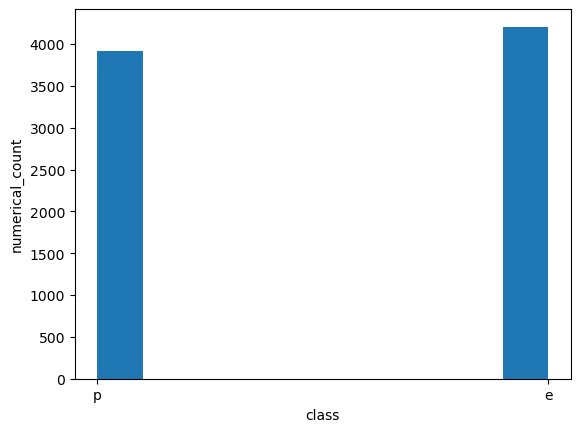

In [8]:
# Histogram
plt.hist(df['class'])#replace with target column
plt.xlabel('class')
plt.ylabel('numerical_count')
plt.show()

In [9]:
# Statistical components analysis
df.describe()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,class
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,6,4,10,2,9,2,2,2,12,2,2
top,x,y,n,f,n,f,c,b,b,t,e
freq,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,4208


In [10]:
# Creating a code that gives the box plots for numeric data type columns all at once
# Made use of for loop and if condition
# plt.boxplot used for its creation
#checking for Outliers
for itr in df.columns:
  if(df[itr].dtypes=='int64' or df[itr].dtypes=='float64'):
    plt.boxplot(df[itr])
    plt.xlabel(itr)
    plt.ylabel('outliers')
    plt.show()

In [11]:
#converting catag columns to numerical
from sklearn.preprocessing import LabelEncoder

label_classes = {}   # store classes for each column

for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_classes[col] = le.classes_   # store class names
        print(col, ":", le.classes_)       # print converted classes

cap-shape : ['b' 'c' 'f' 'k' 's' 'x']
cap-surface : ['f' 'g' 's' 'y']
cap-color : ['b' 'c' 'e' 'g' 'n' 'p' 'r' 'u' 'w' 'y']
bruises : ['f' 't']
odor : ['a' 'c' 'f' 'l' 'm' 'n' 'p' 's' 'y']
gill-attachment : ['a' 'f']
gill-spacing : ['c' 'w']
gill-size : ['b' 'n']
gill-color : ['b' 'e' 'g' 'h' 'k' 'n' 'o' 'p' 'r' 'u' 'w' 'y']
stalk-shape : ['e' 't']
class : ['e' 'p']


In [12]:
#splittng of dataset
x=df.drop(columns=['class'])#replace with your target & unwanted columns
y=df['class']

In [13]:
x

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape
0,5,2,4,1,6,1,0,1,4,0
1,5,2,9,1,0,1,0,0,4,0
2,0,2,8,1,3,1,0,0,5,0
3,5,3,8,1,6,1,0,1,5,0
4,5,2,3,0,5,1,1,0,4,1
...,...,...,...,...,...,...,...,...,...,...
8119,3,2,4,0,5,0,0,0,11,0
8120,5,2,4,0,5,0,0,0,11,0
8121,2,2,4,0,5,0,0,0,5,0
8122,3,3,4,0,8,1,0,1,0,1


In [14]:
y

0       1
1       0
2       0
3       1
4       0
       ..
8119    0
8120    0
8121    0
8122    1
8123    0
Name: class, Length: 8124, dtype: int64

In [15]:
#splitting dataset into training and testing
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [16]:
#checking shape of x_train,x_test,y_train,y_test after splitting of x,y
print(df.shape)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(8124, 11)
(6499, 10)
(1625, 10)
(6499,)
(1625,)


In [17]:
#For Classification
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": Pipeline([
        ("clf", LogisticRegression(max_iter=1000, random_state=50))
    ]),
    
    "Decision Tree": Pipeline([
        ("clf", DecisionTreeClassifier(random_state=50))
    ]),
    
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=100, random_state=50))
    ]),
    
    "XGBoost": Pipeline([
        ("clf", XGBClassifier(eval_metric="logloss", random_state=50))
    ])
}

results = {}
# variables to store models
lr_model = None
dt_model = None
rf_model = None
xgb_model = None

for name, pipeline in models.items():

    pipeline.fit(x_train, y_train)

    train_score = pipeline.score(x_train, y_train)
    test_score = pipeline.score(x_test, y_test)

    results[name] = (train_score, test_score)

    # store models
    if name == "Logistic Regression":
        lr_model = pipeline
    elif name == "Decision Tree":
        dt_model = pipeline
    elif name == "Random Forest":
        rf_model = pipeline
    elif name == "XGBoost":
        xgb_model = pipeline
print("📊 Model Performance (Train vs Test Accuracy):")
for name, (train_acc, test_acc) in results.items():
    print(f"{name:20s} | Train: {train_acc:.3f} | Test: {test_acc:.3f}")

📊 Model Performance (Train vs Test Accuracy):
Logistic Regression  | Train: 0.925 | Test: 0.915
Decision Tree        | Train: 0.999 | Test: 0.999
Random Forest        | Train: 0.999 | Test: 0.999
XGBoost              | Train: 0.999 | Test: 0.999


In [18]:
display_names = {
    "cap-shape": {
        "Bell": "b",
        "Conical": "c",
        "Flat": "f",
        "Knobbed": "k",
        "Sunken": "s",
        "Convex": "x"
    },

    "cap-surface": {
        "Fibrous": "f",
        "Grooved": "g",
        "Smooth": "s",
        "Scaly": "y"
    },

    "cap-color": {
        "Buff": "b",
        "Cinnamon": "c",
        "Red": "e",
        "Gray": "g",
        "Brown": "n",
        "Pink": "p",
        "Green": "r",
        "Purple": "u",
        "White": "w",
        "Yellow": "y"
    },

    "bruises": {
        "No": "f",
        "Yes": "t"
    },

    "odor": {
        "Almond": "a",
        "Creosote": "c",
        "Foul": "f",
        "Anise": "l",
        "Musty": "m",
        "None": "n",
        "Pungent": "p",
        "Spicy": "s",
        "Fishy": "y"
    },

    "gill-attachment": {
        "Attached": "a",
        "Free": "f"
    },

    "gill-spacing": {
        "Close": "c",
        "Crowded": "w"
    },

    "gill-size": {
        "Broad": "b",
        "Narrow": "n"
    },

    "gill-color": {
        "Buff": "b","Red":"e","Gray":"g","Chocolate":"h",
        "Black":"k","Brown":"n","Orange":"o","Pink":"p",
        "Green":"r","Purple":"u","White":"w","Yellow":"y"
    },

    "stalk-shape": {
        "Enlarging": "e",
        "Tapering": "t"
    }
}

In [19]:
#downloading Trained model
import joblib
joblib.dump(dt_model, 'Mushroom Model.pkl')

['Mushroom Model.pkl']

In [ ]:
import tkinter as tk
from tkinter import ttk, messagebox
import numpy as np
import joblib

# Load trained model
model = joblib.load("Mushroom Model.pkl")

# Encoded values used during training
encodings = {
    "cap-shape": ['b','c','f','k','s','x'],
    "cap-surface": ['f','g','s','y'],
    "cap-color": ['b','c','e','g','n','p','r','u','w','y'],
    "bruises": ['f','t'],
    "odor": ['a','c','f','l','m','n','p','s','y'],
    "gill-attachment": ['a','f'],
    "gill-spacing": ['c','w'],
    "gill-size": ['b','n'],
    "gill-color": ['b','e','g','h','k','n','o','p','r','u','w','y'],
    "stalk-shape": ['e','t']
}

# Full names for UI
display_names = {
    "cap-shape": {
        "Bell": "b","Conical": "c","Flat": "f","Knobbed": "k","Sunken": "s","Convex": "x"
    },
    "cap-surface": {
        "Fibrous": "f","Grooved": "g","Smooth": "s","Scaly": "y"
    },
    "cap-color": {
        "Buff": "b","Cinnamon": "c","Red": "e","Gray": "g","Brown": "n",
        "Pink": "p","Green": "r","Purple": "u","White": "w","Yellow": "y"
    },
    "bruises": {
        "No": "f","Yes": "t"
    },
    "odor": {
        "Almond": "a","Creosote": "c","Foul": "f","Anise": "l","Musty": "m",
        "None": "n","Pungent": "p","Spicy": "s","Fishy": "y"
    },
    "gill-attachment": {
        "Attached": "a","Free": "f"
    },
    "gill-spacing": {
        "Close": "c","Crowded": "w"
    },
    "gill-size": {
        "Broad": "b","Narrow": "n"
    },
    "gill-color": {
        "Buff": "b","Red": "e","Gray": "g","Chocolate": "h","Black": "k",
        "Brown": "n","Orange": "o","Pink": "p","Green": "r",
        "Purple": "u","White": "w","Yellow": "y"
    },
    "stalk-shape": {
        "Enlarging": "e","Tapering": "t"
    }
}

class_labels = ['e','p']

# Convert dropdown value to encoded number
def encode_value(column, value):
    code = display_names[column][value]
    return encodings[column].index(code)

# Prediction function
def predict():
    try:
        features = [
            encode_value("cap-shape", cap_shape.get()),
            encode_value("cap-surface", cap_surface.get()),
            encode_value("cap-color", cap_color.get()),
            encode_value("bruises", bruises.get()),
            encode_value("odor", odor.get()),
            encode_value("gill-attachment", gill_attachment.get()),
            encode_value("gill-spacing", gill_spacing.get()),
            encode_value("gill-size", gill_size.get()),
            encode_value("gill-color", gill_color.get()),
            encode_value("stalk-shape", stalk_shape.get())
        ]

        features = np.array(features).reshape(1, -1)

        prediction = model.predict(features)[0]
        result = class_labels[prediction]

        if result == 'e':
            messagebox.showinfo("Result", "🍄 The Mushroom is EDIBLE")
        else:
            messagebox.showinfo("Result", "☠️ The Mushroom is POISONOUS")

    except Exception as e:
        messagebox.showerror("Error", str(e))

# Tkinter Window
root = tk.Tk()
root.title("Mushroom Classification")
root.geometry("420x500")

# Variables
cap_shape = tk.StringVar()
cap_surface = tk.StringVar()
cap_color = tk.StringVar()
bruises = tk.StringVar()
odor = tk.StringVar()
gill_attachment = tk.StringVar()
gill_spacing = tk.StringVar()
gill_size = tk.StringVar()
gill_color = tk.StringVar()
stalk_shape = tk.StringVar()

# Function to create dropdown
def create_dropdown(label, variable, column, row):
    tk.Label(root, text=label).grid(row=row, column=0, padx=10, pady=6, sticky="w")

    options = list(display_names[column].keys())

    ttk.Combobox(
        root,
        textvariable=variable,
        values=options,
        state="readonly",
        width=20
    ).grid(row=row, column=1, padx=10)

# UI Layout
create_dropdown("Cap Shape", cap_shape, "cap-shape", 0)
create_dropdown("Cap Surface", cap_surface, "cap-surface", 1)
create_dropdown("Cap Color", cap_color, "cap-color", 2)
create_dropdown("Bruises", bruises, "bruises", 3)
create_dropdown("Odor", odor, "odor", 4)
create_dropdown("Gill Attachment", gill_attachment, "gill-attachment", 5)
create_dropdown("Gill Spacing", gill_spacing, "gill-spacing", 6)
create_dropdown("Gill Size", gill_size, "gill-size", 7)
create_dropdown("Gill Color", gill_color, "gill-color", 8)
create_dropdown("Stalk Shape", stalk_shape, "stalk-shape", 9)

# Predict Button
tk.Button(root, text="Predict",
          command=predict,
          bg="green",
          fg="white",
          width=15).grid(row=11, column=0, columnspan=2, pady=20)

root.mainloop()

C:\Users\sallu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
